In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [28]:
np.random.seed(42)

n = 10000

data = {
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 80, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 180, n),
    "Sugar_Level": np.random.randint(70, 200, n),
    "Cholesterol": np.random.randint(150, 300, n),
    "Heart_Rate": np.random.randint(60, 120, n)
}

df = pd.DataFrame(data)

df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,1,58,Male,85,190,163,78
1,2,71,Male,155,135,253,89
2,3,48,Male,163,164,231,105
3,4,34,Male,166,133,179,98
4,5,62,Male,109,134,163,103


In [29]:
df.info()

df.isnull().sum()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB


,Patient_ID,Age,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
count,10000.00000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000
mean,5000.50000,49.822000,129.305500,135.1873,224.025500,89.437600
std,2886.89568,17.309144,28.864329,37.5946,43.375147,17.271611
min,1.00000,20.000000,80.000000,70.0000,150.000000,60.000000
25%,2500.75000,35.000000,104.000000,102.0000,186.000000,75.000000
50%,5000.50000,50.000000,130.000000,136.0000,223.000000,89.000000
75%,7500.25000,65.000000,154.000000,168.0000,262.000000,104.000000
max,10000.00000,79.000000,179.000000,199.0000,299.000000,119.000000


In [30]:
# No missing values expected, but just in case
df = df.dropna()

# Convert types if needed
df["Gender"] = df["Gender"].astype("category")

In [31]:
# Function to classify risk
def classify_risk(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 160 or
        row["Cholesterol"] > 240 or
        row["Heart_Rate"] > 100):
        return "High"
    elif (row["Blood_Pressure"] > 120 or
          row["Sugar_Level"] > 140):
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df.apply(classify_risk, axis=1)

df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,1,58,Male,85,190,163,78,High
1,2,71,Male,155,135,253,89,High
2,3,48,Male,163,164,231,105,High
3,4,34,Male,166,133,179,98,High
4,5,62,Male,109,134,163,103,High


In [32]:
# Risk level count
df["Risk_Level"].value_counts()

,count
Risk_Level,
High,8212
Low,906
Medium,882


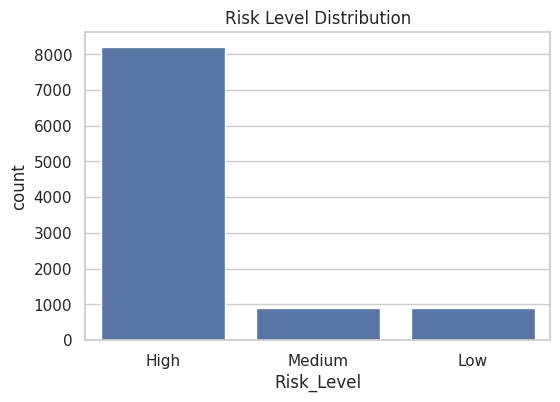

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk_Level", data=df)
plt.title("Risk Level Distribution")
plt.show()

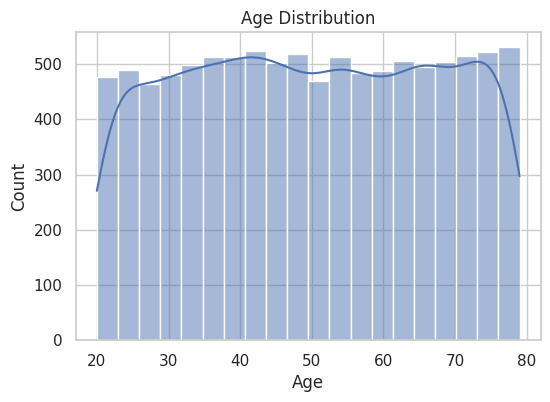

In [34]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

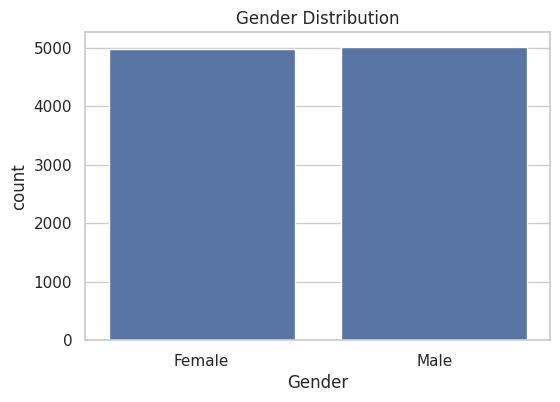

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

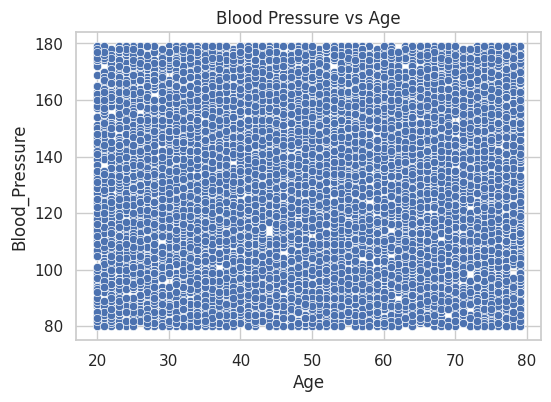

In [36]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Blood_Pressure", data=df)
plt.title("Blood Pressure vs Age")
plt.show()

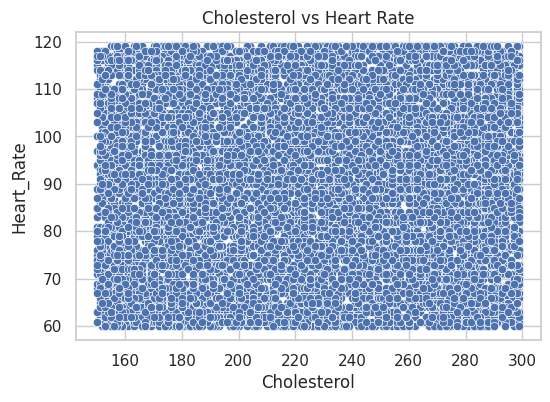

In [37]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Cholesterol", y="Heart_Rate", data=df)
plt.title("Cholesterol vs Heart Rate")
plt.show()

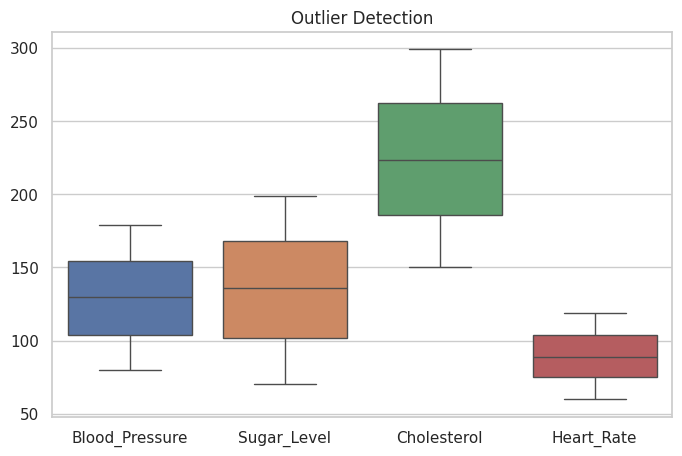

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Blood_Pressure", "Sugar_Level", "Cholesterol", "Heart_Rate"]])
plt.title("Outlier Detection")
plt.show()

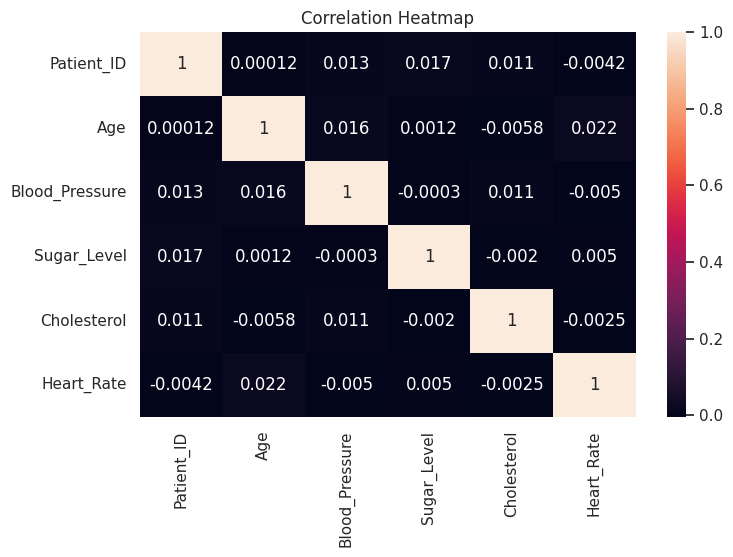

In [39]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [40]:
high_risk = df[df["Risk_Level"] == "High"]

print("Total High Risk Patients:", len(high_risk))

high_risk.head()


Total High Risk Patients: 8212


,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,1,58,Male,85,190,163,78,High
1,2,71,Male,155,135,253,89,High
2,3,48,Male,163,164,231,105,High
3,4,34,Male,166,133,179,98,High
4,5,62,Male,109,134,163,103,High


In [41]:
df.to_csv("healthcare_data.csv", index=False)